# Conserved order-parameter Ising model

This notebook is part of the computational resources for the Statistical Physics course at École Polytechnique. To return to the main repository, follow this link: [https://github.com/cossio/StatPhysCompX](https://github.com/cossio/StatPhysCompX).

Like the standard Ising model, the conserved order-parameter (COP) Ising model is defined by the Hamiltonian:

$$H = -J\sum_{(ij)}s_i s_j$$

where the sum goes over pairs of neighboring sites in a lattice. However, in the COP we impose the constraint that the global magnetization is conserved:

$$\sum_i s_i = Nm$$

where $N$ is the total number of sites in the lattice and $-1 \le m \le 1$, the magnetization per site, is now a fixed parameter of the model. The equilibrium Boltzmann probability distribution is given by:

$$P(\mathbf s) = \frac{1}{Z(J,m)} \exp \left(J\sum_{(ij)}s_i s_j \right) \delta\left( \sum_i s_i; Nm \right)$$

where $\delta(x;y)=1$ if $x=y$ and $\delta(x;y)=0$ otherwise. Configurations $\mathbf s$ that violate the COP constraint have zero probability.

A Hamiltonian of this form can be regarded as a model of an alloy, where a site $s_i=-1$ is interpreted as being occupied by atoms of one type, while $s_i=+1$ corresponds to the same site being occupied by an atom of a different type. The constraint $\sum_i s_i = \text{const.}$ then corresponds to the fact that the total numbers of atoms of each type is conserved.

In this notebook we will simulate the COP Ising model using the **Kawasaki algorithm**.

We will consider a periodic 2-dimensional lattice of size $N = L_1 \times L_2$.

## References

- Newman, M.E.J. et al. (1999) Monte Carlo Methods in Statistical Physics. Oxford University Press (Chapter 5).

The Kawasaki algorithm is a Monte-Carlo routine to simulate the COP Ising model. In the standard Metropolis algorithm, a flip of a random spin is proposed each time step, which is then accepted or not according to Metropolis rule. However, by flipping just a single spin it is impossible to conserve the global magnetization of the lattice.

Instead, we can propose to *exchange* two spins. We choose a random pair of spins on the lattice. Rather than flipping them, we swap their values. Then we decide whether to accept this move according to the standard Metropolis rule.

Note that swapping two spins of the same sign has no effect. We therefore only attempt swaps between a spin pointing up and a spin pointing down.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

In [2]:
def init_lattice(L1, L2, M):
    """
    Initialize a random lattice with fixed boundary conditions and total magnetization M.
    First column is fixed to +1, last column to -1 (breaks translation symmetry).
    Interior sites are randomized to achieve the desired magnetization.
    """
    sigma = np.zeros((L1, L2), dtype=np.int8)
    sigma[:, 0] = 1   # first column: all up
    sigma[:, -1] = 0   # last column: all down

    # Boundary contributes magnetization: L1*(+1) + L1*(-1) = 0 in {-1,+1} convention
    # Interior has L1*(L2-2) sites. Need interior magnetization = M.
    n_interior = L1 * (L2 - 2)
    n_up = (M + n_interior) // 2  # number of up spins in interior
    assert 0 <= n_up <= n_interior, f"Magnetization M={M} not achievable"

    interior = np.zeros(n_interior, dtype=np.int8)
    interior[:n_up] = 1
    np.random.shuffle(interior)
    sigma[:, 1:-1] = interior.reshape(L1, L2 - 2)
    return sigma

In [3]:
@njit
def _kawasaki_sweep(sigma, J, L1, L2, n_steps):
    """Perform n_steps Kawasaki swap attempts (in-place). Only interior sites are swapped."""
    for _ in range(n_steps):
        # Pick two random interior sites (columns 1 to L2-2)
        i1 = np.random.randint(0, L1)
        j1 = np.random.randint(1, L2 - 1)
        i2 = np.random.randint(0, L1)
        j2 = np.random.randint(1, L2 - 1)

        # Only attempt swap if spins are different
        if sigma[i1, j1] == sigma[i2, j2]:
            continue

        # Neighbor sums (counting sigma values 0/1)
        nb1 = (sigma[(i1-1)%L1, j1] + sigma[(i1+1)%L1, j1] +
               sigma[i1, (j1-1)%L2] + sigma[i1, (j1+1)%L2])
        nb2 = (sigma[(i2-1)%L1, j2] + sigma[(i2+1)%L1, j2] +
               sigma[i2, (j2-1)%L2] + sigma[i2, (j2+1)%L2])

        # Energy change for swapping: dE = 4*J*(sigma[i2,j2] - sigma[i1,j1])*(nb2 - nb1)
        dE = 4.0 * J * (sigma[i2, j2] - sigma[i1, j1]) * (nb2 - nb1)

        if dE <= 0.0 or np.random.random() < np.exp(-dE):
            sigma[i1, j1], sigma[i2, j2] = sigma[i2, j2], sigma[i1, j1]


def kawasaki(J, L1, L2, M, steps_between_frames, number_of_frames):
    """Run Kawasaki simulation. Returns (final_config, list_of_snapshots)."""
    sigma = init_lattice(L1, L2, M)
    # Store a few snapshots for visualization
    snapshot_times = [number_of_frames // 4, number_of_frames // 2, number_of_frames - 1]
    snapshots = {}
    for f in range(1, number_of_frames):
        _kawasaki_sweep(sigma, J, L1, L2, steps_between_frames)
        if f in snapshot_times:
            snapshots[f] = sigma.copy()
    return sigma.copy(), snapshots

In [4]:
# Warm up numba JIT
_ = kawasaki(0.4, 10, 10, 0, 100, 10)

We will do simulations at increasing values of $J$ (equivalently, decreasing values of the temperature).

In [5]:
values_of_J = [0.1, 0.4, 0.5, 1.0]

simulations = {}
for J in values_of_J:
    print(f"Simulating J={J}...")
    snap, snapshots = kawasaki(J, L1=100, L2=50, M=0,
                               steps_between_frames=4000, number_of_frames=25_000)
    simulations[J] = snap
    print(f"  done.")

Simulating J=0.1...
  done.
Simulating J=0.4...
  done.
Simulating J=0.5...
  done.
Simulating J=1.0...
  done.


Let's take a look at some typical snapshots of the simulations we just did.

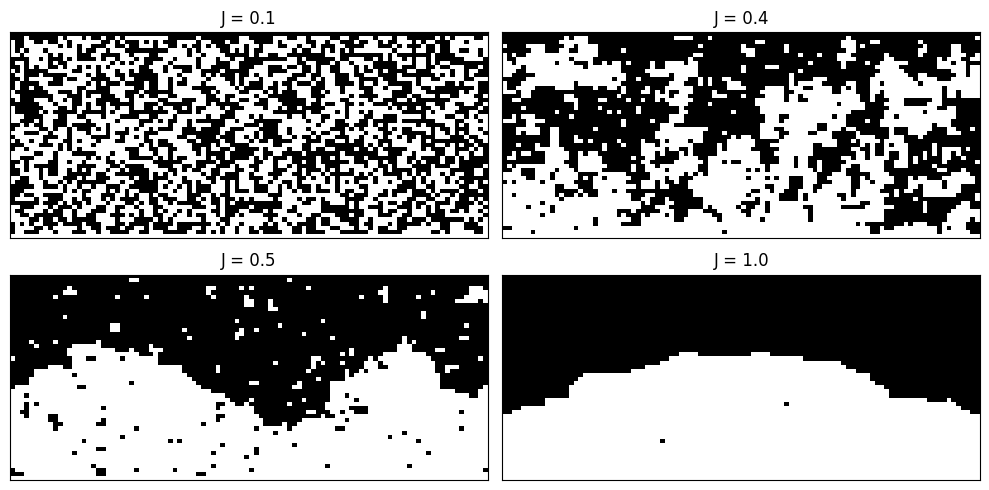

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 5))
for ax, J in zip(axes.flat, values_of_J):
    ax.imshow(simulations[J].T, cmap="gray_r", interpolation="nearest",
              vmin=0, vmax=1, aspect="auto")
    ax.set_title(f"J = {J}")
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()